# 05 — LSTM Agent **v3**: Training & Backtest

Ta sama ścieżka danych i LSTM co w v2; zmienia się **logika handlu**: minimalny czas przed wyjściem po pewności modelu (**2 h**), maksymalny czas w pozycji (**24 h**), umiarkowane progi wejścia/wyjścia i krótszy cooldown — chodzi o to, by uniknąć skrajności v1 (setki transakcji, średnio ~2 h w pozycji) oraz v2 (0 transakcji przy progu 0.65).


In [1]:
# ── Configuration — v3 (edit here) ─────────────────────────────────────────
SYMBOL        = 'BTCUSDT'
INTERVAL      = '1h'

# Calendar split (jak w v2 — bez zmian)
TRAIN_END     = '2024-06-01'
VAL_END       = '2024-11-10'
TEST_START    = '2024-11-10'

SEQ_LEN       = 168            # lookback 7 dni (1h)

LSTM_UNITS    = 64
NUM_LAYERS    = 2
DROPOUT       = 0.4
EPOCHS        = 50
BATCH_SIZE    = 256
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 12

# Trading — v3: 2h min / 24h max (świece 1h); częstotliwość między v1 a v2
CONFIDENCE_THRESHOLD = 0.56    # niżej niż v2 (0.65), żeby były sygnały
EXIT_THRESHOLD       = 0.48    # histereza względem wejścia
MIN_HOLD_CANDLES     = 2       # min. 2h przed wyjściem po spadku P(up)
MAX_HOLD_CANDLES     = 24      # wymuszone wyjście po 24h w pozycji
COOLDOWN_CANDLES     = 6       # krócej niż v2 (12) — umiarkowana rotacja
TAKE_PROFIT          = 0.03
STOP_LOSS            = 0.02
FEE                  = 0.0005

# Jeśli liczba transakcji nadal odbiega od celu: najpierw CONFIDENCE_THRESHOLD (np. 0.54–0.58), potem COOLDOWN.

SEED = 42


In [2]:
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from hmats.data.binance_store import load
from hmats.data.features import FEATURE_COLS, make_features
from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'; RED='#EF5350'; GREEN='#26A69A'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
RAW_DIR     = REPO_ROOT / 'data' / 'raw'
MODELS_DIR  = REPO_ROOT / 'models'
FIGURES_DIR = REPO_ROOT / 'figures'
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


Device: mps


## 1. Load & prepare data

In [3]:
raw = load(SYMBOL, INTERVAL, store_dir=str(RAW_DIR))
raw.index = raw.index.tz_localize(None) if raw.index.tz else raw.index
feat_df = make_features(raw)
feat_df['label'] = (feat_df['close'].shift(-1) > feat_df['close']).astype(int)
feat_df = feat_df.dropna()

train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)

print(f'Train: {len(train_df):>7,} rows  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val:   {len(val_df):>7,} rows  {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test:  {len(test_df):>7,} rows  {test_df.index.min().date()} → {test_df.index.max().date()}')
print(f'Label balance — train: {train_df["label"].mean():.3f}  val: {val_df["label"].mean():.3f}  test: {test_df["label"].mean():.3f}')


Train:  59,317 rows  2017-08-20 → 2024-06-01
Val:     3,888 rows  2024-06-01 → 2024-11-10
Test:   12,960 rows  2024-11-10 → 2026-05-04
Label balance — train: 0.510  val: 0.505  test: 0.504


## 2. Normalisation & sequences

Standardise with **train-set statistics only**. Val and test sets use the same `mu`/`sd` — no leakage.

In [4]:
X_cols = FEATURE_COLS
mu = train_df[X_cols].mean().values.astype(np.float32)
sd = (train_df[X_cols].std().values + 1e-8).astype(np.float32)
np.savez(MODELS_DIR / 'lstm_scaler_v3.npz', mu=mu, sd=sd)

def make_sequences(df, seq_len=SEQ_LEN):
    X_raw = ((df[X_cols].values - mu) / sd).astype(np.float32)
    y_raw = df['label'].values.astype(np.float32)
    Xs, ys = [], []
    for i in range(seq_len, len(X_raw)):
        Xs.append(X_raw[i - seq_len:i])
        ys.append(y_raw[i])
    return np.array(Xs), np.array(ys)

X_train, y_train = make_sequences(train_df)
X_val,   y_val   = make_sequences(val_df)
X_test,  y_test  = make_sequences(test_df)

print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')


X_train: (59149, 168, 12)  X_val: (3720, 168, 12)  X_test: (12792, 168, 12)


## 3. Model

In [5]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.norm    = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.norm(out[:, -1])   # LayerNorm on last timestep
        out = self.dropout(out)
        return self.head(out).squeeze(-1)


model = LSTMClassifier(
    input_dim=len(X_cols),
    hidden_dim=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


LSTMClassifier(
  (lstm): LSTM(12, 64, num_layers=2, batch_first=True, dropout=0.4)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
    (4): Sigmoid()
  )
)
Parameters: 55,489


## 4. Training with early stopping

Validation loss is tracked each epoch. If it does not improve for `PATIENCE` epochs the best checkpoint is restored and training stops.

In [6]:
train_ds     = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds       = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss   = float('inf')
patience_count  = 0
best_state      = None
stopped_epoch   = EPOCHS

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss    += loss.item() * len(xb)
        t_correct += ((preds > 0.5) == yb.bool()).sum().item()
        t_total   += len(xb)

    # ── Validate ──
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds   = model(xb)
            v_loss    += criterion(preds, yb).item() * len(xb)
            v_correct += ((preds > 0.5) == yb.bool()).sum().item()
            v_total   += len(xb)

    avg_t_loss = t_loss / t_total
    avg_v_loss = v_loss / v_total
    t_acc = t_correct / t_total
    v_acc = v_correct / v_total

    history['train_loss'].append(avg_t_loss)
    history['val_loss'].append(avg_v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    scheduler.step(avg_v_loss)

    # ── Early stopping ──
    if avg_v_loss < best_val_loss:
        best_val_loss  = avg_v_loss
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            stopped_epoch = epoch
            print(f'Early stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})')
            break

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{EPOCHS}  '
              f'train_loss={avg_t_loss:.4f}  val_loss={avg_v_loss:.4f}  '
              f'train_acc={t_acc:.4f}  val_acc={v_acc:.4f}')

# Restore best checkpoint
model.load_state_dict(best_state)
torch.save(model.state_dict(), MODELS_DIR / 'lstm_model_v3.pt')
print(f'Best model restored and saved (val_loss={best_val_loss:.4f})')


Epoch   1/50  train_loss=0.6947  val_loss=0.6935  train_acc=0.5065  val_acc=0.5038
Epoch   5/50  train_loss=0.6927  val_loss=0.6938  train_acc=0.5125  val_acc=0.4968
Epoch  10/50  train_loss=0.6919  val_loss=0.6937  train_acc=0.5200  val_acc=0.5105
Early stopping at epoch 14 (best val loss: 0.6934)
Best model restored and saved (val_loss=0.6934)


### Training curves

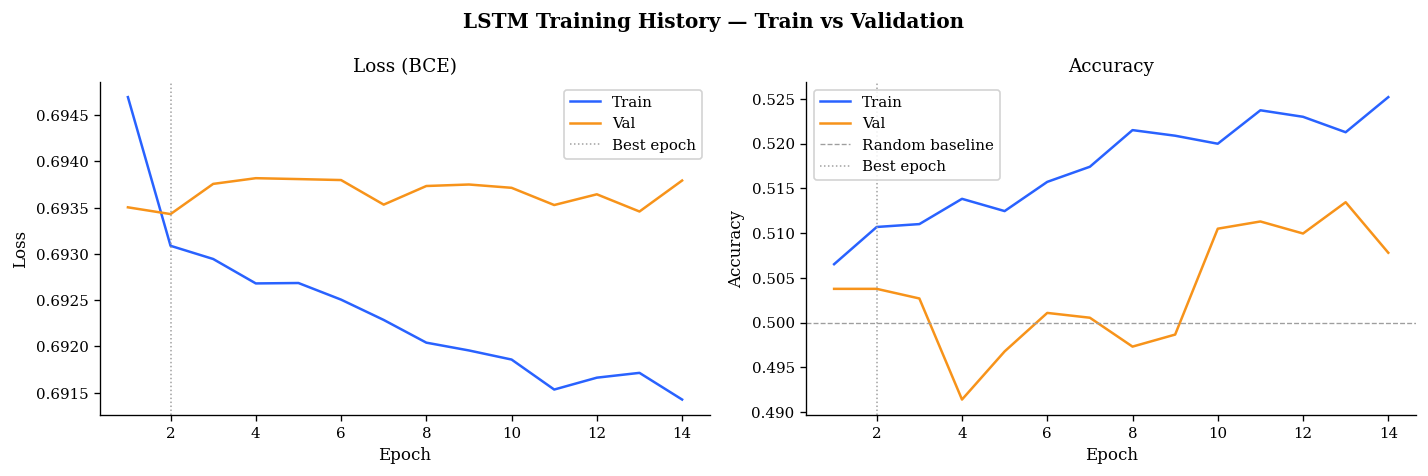

Final train acc: 0.5252
Final val acc:   0.5078
Overfitting gap: 0.0174  (acceptable)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_ran = range(1, len(history['train_loss']) + 1)

ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], color=BLUE,  lw=1.5, label='Train')
ax.plot(epochs_ran, history['val_loss'],   color=ACCENT, lw=1.5, label='Val')
ax.axvline(stopped_epoch - PATIENCE, color=GREY, ls=':', lw=0.9, label='Best epoch')
ax.set_title('Loss (BCE)'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend()

ax = axes[1]
ax.plot(epochs_ran, history['train_acc'], color=BLUE,   lw=1.5, label='Train')
ax.plot(epochs_ran, history['val_acc'],   color=ACCENT, lw=1.5, label='Val')
ax.axhline(0.5, color=GREY, ls='--', lw=0.8, label='Random baseline')
ax.axvline(stopped_epoch - PATIENCE, color=GREY, ls=':', lw=0.9, label='Best epoch')
ax.set_title('Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend()

fig.suptitle('LSTM Training History — Train vs Validation', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'lstm_training_history.png')
plt.show()

gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f'Final train acc: {history["train_acc"][-1]:.4f}')
print(f'Final val acc:   {history["val_acc"][-1]:.4f}')
print(f'Overfitting gap: {gap:.4f}  {"(acceptable)" if gap < 0.05 else "(overfitting — consider more dropout)"}')


## 5. Test-set evaluation

In [8]:
model.eval()
with torch.no_grad():
    X_t   = torch.from_numpy(X_test).to(DEVICE)
    probs = model(X_t).cpu().numpy()

signal_index = test_df.index[SEQ_LEN:]
close_prices = test_df['close'].values[SEQ_LEN:]

test_acc = ((probs > 0.5) == y_test).mean()
val_acc_final = history['val_acc'][stopped_epoch - PATIENCE - 1]
print(f'Val  accuracy (best epoch): {val_acc_final:.4f}')
print(f'Test accuracy:              {test_acc:.4f}')
print(f'Signals above entry threshold ({CONFIDENCE_THRESHOLD}): '
      f'{(probs >= CONFIDENCE_THRESHOLD).sum():,} / {len(probs):,}')


Val  accuracy (best epoch): 0.5038
Test accuracy:              0.5034
Signals above entry threshold (0.56): 0 / 12,792


## 6. Backtest

**Wejście:** `P(up)` ≥ `CONFIDENCE_THRESHOLD`, brak pozycji, koniec cooldownu.

**Wyjście (kolejność):**
1. Stop-loss (`STOP_LOSS`)
2. Take-profit (`TAKE_PROFIT`)
3. **Limit czasu:** w pozycji ≥ `MAX_HOLD_CANDLES` godzin (interwał 1h ⇒ liczba świec)
4. **Pewność:** `P(up)` < `EXIT_THRESHOLD` **oraz** w pozycji ≥ `MIN_HOLD_CANDLES` godzin

SL/TP działają od pierwszej świecy po wejściu (bez minimalnego holdu), tak jak w v2.


In [9]:
equity      = 1.0
cash        = 1.0
units       = 0.0
in_pos      = False
entry_px    = 0.0
entry_ts    = None
hold_count  = 0
cooldown    = 0

equity_curve = [equity]
trade_log    = []

for i, (ts, px, conf) in enumerate(zip(signal_index, close_prices, probs)):
    if cooldown > 0:
        cooldown -= 1

    if in_pos:
        hold_count += 1
        pnl_pct = (px - entry_px) / entry_px
        reason  = None

        if pnl_pct <= -STOP_LOSS:
            reason = 'sl'
        elif pnl_pct >= TAKE_PROFIT:
            reason = 'tp'
        elif hold_count >= MAX_HOLD_CANDLES:
            reason = 'max_hold'
        elif hold_count >= MIN_HOLD_CANDLES and conf < EXIT_THRESHOLD:
            reason = 'conf'

        if reason:
            proceeds = units * px * (1 - FEE)
            trade_log.append({
                'entry_time': entry_ts, 'exit_time': ts,
                'entry_px':   entry_px, 'exit_px':  px,
                'pnl_pct':    pnl_pct,  'reason':   reason,
                'hold_h':     hold_count,
            })
            cash       = proceeds
            units      = 0.0
            in_pos     = False
            hold_count = 0
            cooldown   = COOLDOWN_CANDLES

    if not in_pos and cooldown == 0 and conf >= CONFIDENCE_THRESHOLD:
        spend    = cash * (1 - FEE)
        units    = spend / px
        cash     = 0.0
        in_pos   = True
        entry_px = px
        entry_ts = ts
        hold_count = 0

    equity_curve.append(cash + units * px)

if in_pos:
    px = close_prices[-1]
    proceeds = units * px * (1 - FEE)
    trade_log.append({
        'entry_time': entry_ts, 'exit_time': signal_index[-1],
        'entry_px': entry_px,   'exit_px': px,
        'pnl_pct': (px - entry_px) / entry_px,
        'reason': 'eod', 'hold_h': hold_count,
    })
    equity_curve[-1] = proceeds

equity_arr = np.array(equity_curve[1:])
trades_df  = pd.DataFrame(trade_log)
print(f'Total trades: {len(trades_df)}')
if not trades_df.empty:
    print(trades_df['reason'].value_counts().to_string())
    print(f'Avg holding time:    {trades_df["hold_h"].mean():.1f}h')
    print(f'Median holding time: {trades_df["hold_h"].median():.1f}h')


Total trades: 0


## 7. Buy-and-hold benchmark

In [10]:
bh_units  = (1.0 * (1 - FEE)) / close_prices[0]
bh_equity = bh_units * close_prices
bh_final  = bh_units * close_prices[-1] * (1 - FEE)


## 8. Metrics

In [11]:
def sharpe(returns, ann_factor=24*365):
    """Annualised Sharpe on per-step log returns; undefined if returns are ~constant."""
    r = np.asarray(returns, dtype=np.float64)
    if len(r) < 2:
        return 0.0
    sd = float(np.std(r, ddof=1))
    if not np.isfinite(sd) or sd < 1e-15:
        return 0.0
    return float((r.mean() / sd) * np.sqrt(ann_factor))

def max_dd(equity):
    eq   = np.asarray(equity, dtype=np.float64)
    peak = np.maximum.accumulate(eq)
    return float(((eq - peak) / (peak + 1e-12)).min())

def log_rets(equity):
    eq = np.asarray(equity, dtype=np.float64)
    prev = np.maximum(eq[:-1], 1e-12)
    return np.log(eq[1:] / prev)

metrics = pd.DataFrame([
    {
        'Strategy':      'LSTM Agent',
        'Total Return':  f'{(equity_arr[-1] - 1) * 100:.2f}%',
        'Sharpe (ann.)': f'{sharpe(log_rets(equity_arr)):.3f}',
        'Max Drawdown':  f'{max_dd(equity_arr) * 100:.2f}%',
        'Num Trades':    len(trades_df),
        'Win Rate':      f'{(trades_df["pnl_pct"] > 0).mean() * 100:.1f}%' if not trades_df.empty else 'N/A',
        'Avg Hold (h)':  f'{trades_df["hold_h"].mean():.1f}' if not trades_df.empty else 'N/A',
        'Avg PnL/Trade': f'{trades_df["pnl_pct"].mean() * 100:.2f}%' if not trades_df.empty else 'N/A',
    },
    {
        'Strategy':      'Buy & Hold',
        'Total Return':  f'{(bh_final - 1) * 100:.2f}%',
        'Sharpe (ann.)': f'{sharpe(log_rets(bh_equity)):.3f}',
        'Max Drawdown':  f'{max_dd(bh_equity) * 100:.2f}%',
        'Num Trades':    1,
        'Win Rate':      'N/A',
        'Avg Hold (h)':  'N/A',
        'Avg PnL/Trade': 'N/A',
    },
]).set_index('Strategy')

print(metrics.to_string())


           Total Return Sharpe (ann.) Max Drawdown  Num Trades Win Rate Avg Hold (h) Avg PnL/Trade
Strategy                                                                                          
LSTM Agent        0.00%         0.000        0.00%           0      N/A          N/A           N/A
Buy & Hold      -13.08%        -0.207      -50.08%           1      N/A          N/A           N/A


## 9. Results visualisation

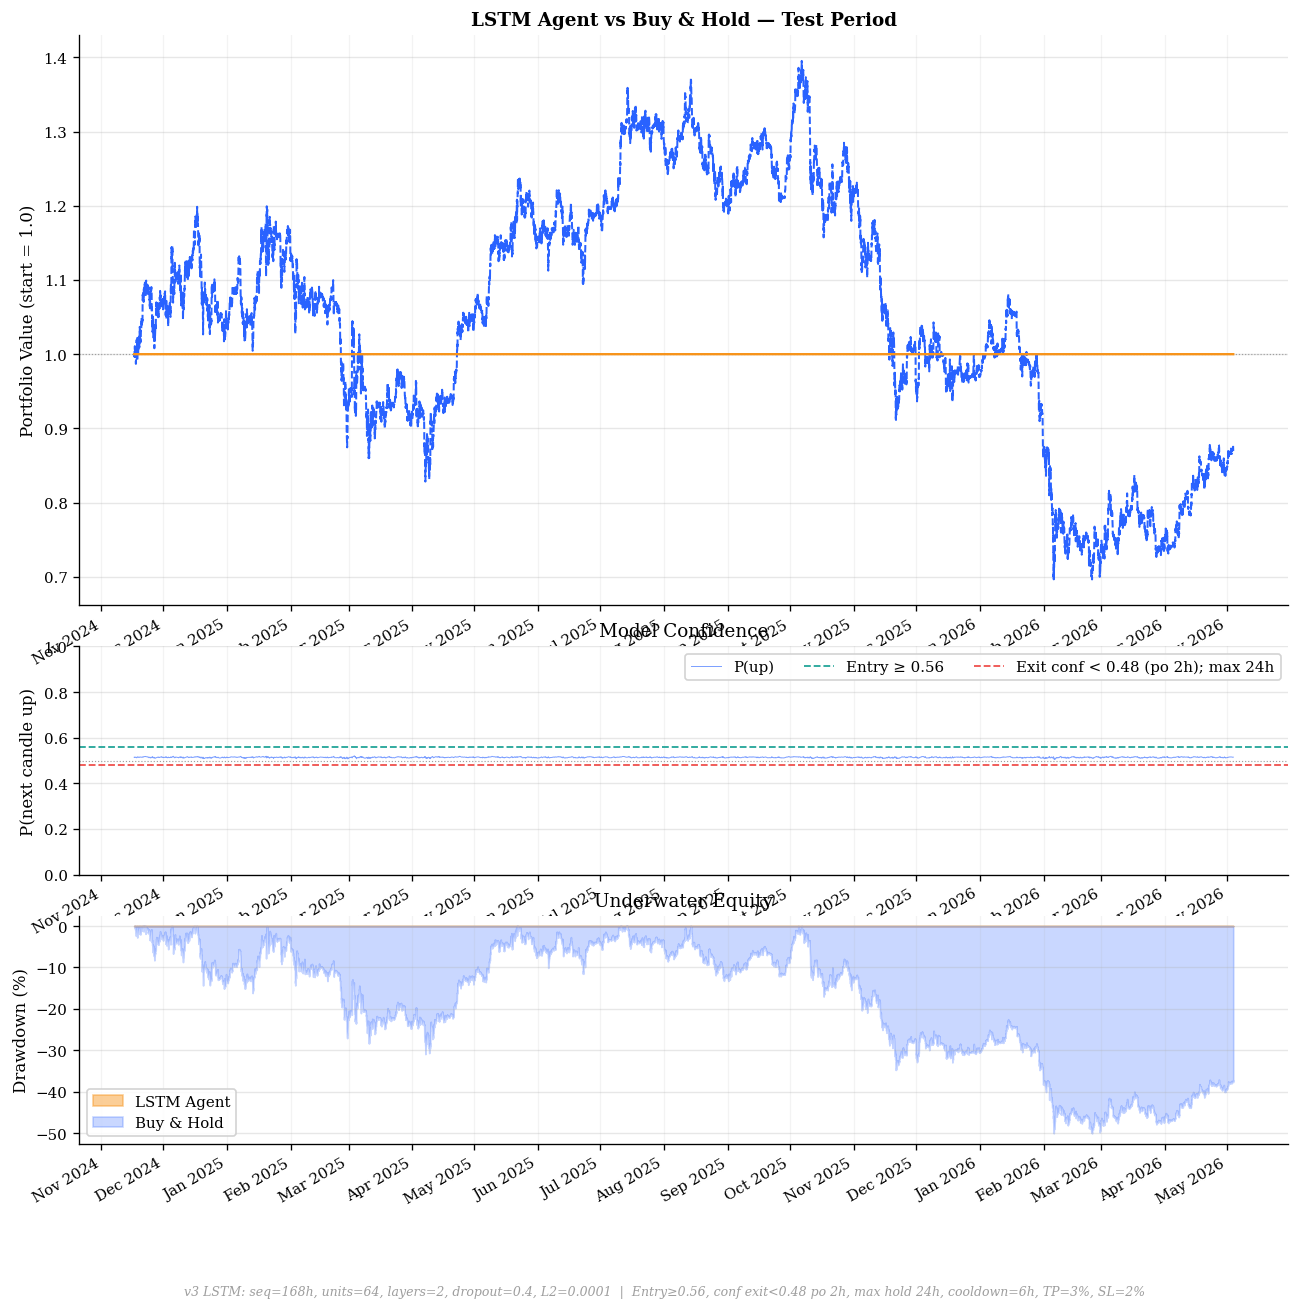

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12),
                         gridspec_kw={'height_ratios': [3, 1.2, 1.2], 'hspace': 0.12})

# ── Equity curves ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(signal_index, equity_arr, color=ACCENT, lw=1.4, label='LSTM Agent', zorder=3)
ax.plot(signal_index, bh_equity,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold', zorder=2)
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
if not trades_df.empty:
    eq_series = pd.Series(equity_arr, index=signal_index)
    for _, row in trades_df.iterrows():
        ev = eq_series.index.get_indexer([row['entry_time']], method='nearest')[0]
        xv = eq_series.index.get_indexer([row['exit_time']],  method='nearest')[0]
        ax.scatter(eq_series.index[ev], equity_arr[ev], marker='^', color=GREEN, s=35, zorder=5)
        ax.scatter(eq_series.index[xv], equity_arr[xv], marker='v', color=RED,   s=35, zorder=5)
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        *ax.get_legend_handles_labels()[0][:2],
        Line2D([0],[0], marker='^', color='w', markerfacecolor=GREEN, markersize=8, label='Entry'),
        Line2D([0],[0], marker='v', color='w', markerfacecolor=RED,   markersize=8, label='Exit'),
    ], ncol=2)
ax.set_ylabel('Portfolio Value (start = 1.0)')
ax.set_title('LSTM Agent vs Buy & Hold — Test Period', fontweight='bold')
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── Confidence ────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(signal_index, probs, color=BLUE, lw=0.6, alpha=0.6, label='P(up)')
ax.axhline(CONFIDENCE_THRESHOLD, color=GREEN, ls='--', lw=1.1,
           label=f'Entry ≥ {CONFIDENCE_THRESHOLD}')
ax.axhline(EXIT_THRESHOLD, color=RED, ls='--', lw=1.1,
           label=f'Exit conf < {EXIT_THRESHOLD} (po {MIN_HOLD_CANDLES}h); max {MAX_HOLD_CANDLES}h')
ax.axhline(0.5, color=GREY, ls=':', lw=0.7)
ax.set_ylim(0, 1); ax.set_ylabel('P(next candle up)')
ax.set_title('Model Confidence'); ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── Drawdown ──────────────────────────────────────────────────────────────────
ax = axes[2]
peak_l = np.maximum.accumulate(equity_arr)
peak_b = np.maximum.accumulate(bh_equity)
dd_l   = (equity_arr - peak_l) / (peak_l + 1e-12) * 100
dd_b   = (bh_equity  - peak_b) / (peak_b  + 1e-12) * 100
ax.fill_between(signal_index, dd_l, 0, color=ACCENT, alpha=0.45, label='LSTM Agent')
ax.fill_between(signal_index, dd_b, 0, color=BLUE,   alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.set_title('Underwater Equity')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'v3 LSTM: seq={SEQ_LEN}h, units={LSTM_UNITS}, layers={NUM_LAYERS}, dropout={DROPOUT}, '
    f'L2={WEIGHT_DECAY}  |  '
    f'Entry≥{CONFIDENCE_THRESHOLD}, conf exit<{EXIT_THRESHOLD} po {MIN_HOLD_CANDLES}h, max hold {MAX_HOLD_CANDLES}h, '
    f'cooldown={COOLDOWN_CANDLES}h, TP={TAKE_PROFIT*100:.0f}%, SL={STOP_LOSS*100:.0f}%',
    ha='center', fontsize=7.5, color=GREY, style='italic')

fig.savefig(FIGURES_DIR / 'lstm_backtest_results_v3.png')
plt.show()


## 10. Trade log

In [13]:
if not trades_df.empty:
    trades_df['pnl_fmt'] = trades_df['pnl_pct'].apply(lambda x: f'{x*100:+.2f}%')
    display(trades_df[['entry_time','exit_time','hold_h','entry_px','exit_px','pnl_fmt','reason']])


In [14]:
# ── Percentyle pewności P(up) w czasie ───────────────────────────────────────
from IPython.display import display

conf = pd.Series(np.asarray(probs).ravel(), index=signal_index, name='P_up')

# Cały okres testowy (jeden rozkład)
static_levels = [1, 5, 10, 25, 50, 75, 90, 95, 99]
static_tbl = pd.DataFrame(
    {'percentyl_%': static_levels, 'P_up': [conf.quantile(p / 100.0) for p in static_levels]}
)
print('Percentyle P(up) — cały okres testowy')
display(static_tbl)

# Rolling: percentyle rozkładu P(up) w przesuwającym się oknie (jak zmienia się „kształt” szeregu)
ROLL_WINDOW = 336  # h (2 tygodnie przy 1h); np. 168 = 1 tydzień
min_periods = max(48, ROLL_WINDOW // 8)
roll_pct = pd.DataFrame({
    f'p{p}': conf.rolling(ROLL_WINDOW, min_periods=min_periods).quantile(p / 100.0)
    for p in (5, 10, 25, 50, 75, 90, 95)
})
print(f'Rolling percentyle P(up), okno={ROLL_WINDOW}h (pierwsze / ostatnie wiersze bez NaN):')
display(roll_pct.dropna().head(10))
display(roll_pct.dropna().tail(10))


Percentyle P(up) — cały okres testowy


,percentyl_%,P_up
0,1,0.509820
1,5,0.511020
2,10,0.511644
3,25,0.512550
4,50,0.513828
5,75,0.515006
6,90,0.516024
7,95,0.516547
8,99,0.517429


Rolling percentyle P(up), okno=336h (pierwsze / ostatnie wiersze bez NaN):


,p5,p10,p25,p50,p75,p90,p95
open_time,,,,,,,
2024-11-19 00:00:00,0.512373,0.512456,0.513586,0.514159,0.514822,0.515310,0.515592
2024-11-19 01:00:00,0.512376,0.512457,0.513636,0.514183,0.514918,0.515285,0.515587
2024-11-19 02:00:00,0.512380,0.512458,0.513639,0.514232,0.514929,0.515260,0.515581
2024-11-19 03:00:00,0.512383,0.512458,0.513642,0.514280,0.514925,0.515235,0.515576
2024-11-19 04:00:00,0.512386,0.512505,0.513645,0.514232,0.514922,0.515233,0.515571
2024-11-19 05:00:00,0.512389,0.512552,0.513648,0.514183,0.514918,0.515232,0.515565
2024-11-19 06:00:00,0.512393,0.512599,0.513639,0.514159,0.514884,0.515230,0.515560
2024-11-19 07:00:00,0.512396,0.512646,0.513593,0.514134,0.514851,0.515229,0.515554
2024-11-19 08:00:00,0.512399,0.512692,0.513615,0.514125,0.514818,0.515228,0.515549


,p5,p10,p25,p50,p75,p90,p95
open_time,,,,,,,
2026-05-03 15:00:00,0.511785,0.511959,0.512779,0.513886,0.515098,0.515694,0.516285
2026-05-03 16:00:00,0.511785,0.511959,0.512808,0.513893,0.515098,0.515694,0.516285
2026-05-03 17:00:00,0.511785,0.511959,0.512808,0.513901,0.515098,0.515694,0.516285
2026-05-03 18:00:00,0.511785,0.511959,0.512808,0.513916,0.515098,0.515694,0.516285
2026-05-03 19:00:00,0.511785,0.511959,0.512808,0.513916,0.515098,0.515694,0.516285
2026-05-03 20:00:00,0.511785,0.511959,0.512808,0.513930,0.515098,0.515694,0.516285
2026-05-03 21:00:00,0.511785,0.511959,0.512808,0.513932,0.515098,0.515694,0.516285
2026-05-03 22:00:00,0.511785,0.511959,0.512808,0.513936,0.515098,0.515694,0.516285
2026-05-03 23:00:00,0.511785,0.511959,0.512808,0.513936,0.515098,0.515694,0.516285
